In [9]:
import numpy as np  # matrix
import random

dim = 2  # base case
add_count = 0
mul_count = 0
shift_count = 0
n_123 = 100  # base case
q = 3329
flip = 90


def mul_NTT_c(poly1: np.ndarray, poly2: np.ndarray) -> np.ndarray:
    """
        Uses the NTT method to multiply two polynomials modulo MOD.
        Highest order last.
        Example: (1+2x)(2+3x) = 2 + 7x + 6x^2

        This version prints the amount of additions, multiplications, and bit shifts.

        requirements:
            numpy

        examples:
        >>> mul_NTT_c([1, 2], [2, 3])
        Total multiplications: 9, additions/subtractions: 0, bit shifts: 0
        array([2 7 6 0 0])
        >>> mul_NTT_c([6, 10, 3, 12], [5, 2, 7, 9])
        Total multiplications: 20, additions/subtractions: 67, bit shifts: 8
        array([ 30,  62,  77, 190,  78, -79,  34, 174, 146,   0,   0])
    """

    MOD = 998244353  # large prime modulus
    ROOT = 3  # primitive root modulo MOD

    # convert input
    if isinstance(poly1, (list, tuple)):
        poly1 = np.array(poly1, dtype=int)
    if isinstance(poly2, (list, tuple)):
        poly2 = np.array(poly2, dtype=int)

    # checks
    assert isinstance(poly1, np.ndarray), "poly1 must be a numpy array."
    assert isinstance(poly2, np.ndarray), "poly2 must be a numpy array."

    assert np.issubdtype(poly1.dtype, np.integer), "All elements of poly1 must be int."
    assert np.issubdtype(poly2.dtype, np.integer), "All elements of poly2 must be int."

    # trivial solution
    if np.all(poly1 == 0) or np.all(poly2 == 0):
        print(f"Total multiplications: 0, additions/subtractions: 0, bit shifts: 0")
        return np.array([0], dtype=int)

    # counters
    global add_count, mul_count, shift_count

    def mod_pow(base, exp, mod):
        global mul_count, shift_count
        result = 1
        base %= mod
        while exp > 0:
            if exp & 1:
                result = (result * base) % mod
                mul_count += 1
            base = (base * base) % mod
            mul_count += 1
            exp >>= 1
            shift_count += 1
        return result

    def bit_reverse_permute(a):
        # In-place bit-reversal permutation
        global add_count, shift_count
        n = len(a)
        j = 0
        for i in range(1, n):
            bit = n >> 1
            while j & bit:
                j ^= bit
                bit >>= 1
                shift_count += 1
            j ^= bit
            if i < j:
                a[i], a[j] = a[j], a[i]
                add_count += 2  # count swap as two assignments

    def NTT(a, invert=False):
        global add_count, mul_count, shift_count
        n = len(a)
        bit_reverse_permute(a)

        length = 2
        while length <= n:
            wlen = mod_pow(ROOT, (MOD - 1) // length, MOD)
            if invert:
                wlen = mod_pow(wlen, MOD - 2, MOD)
            for i in range(0, n, length):
                w = 1
                half = length // 2
                for j in range(i, i + half):
                    u = a[j]
                    v = (a[j + half] * w) % MOD
                    mul_count += 1
                    a[j] = (u + v) % MOD
                    a[j + half] = (u - v) % MOD
                    if a[j + half] < 0:
                        a[j + half] += MOD
                    add_count += 2
                    w = (w * wlen) % MOD
                    mul_count += 1
            length <<= 1
            shift_count += 1

        if invert:
            inv_n = mod_pow(n, MOD - 2, MOD)
            for i in range(n):
                a[i] = (a[i] * inv_n) % MOD
                mul_count += 1

        return a

    needed = len(poly1) + len(poly2) - 1
    n = 1
    while n < needed:
        n <<= 1
        shift_count += 1

    f = [int(x) % MOD for x in poly1] + [0] * (n - len(poly1))
    g = [int(x) % MOD for x in poly2] + [0] * (n - len(poly2))

    NTT(f, invert=False)
    NTT(g, invert=False)

    for i in range(n):
        f[i] = (f[i] * g[i]) % MOD
        mul_count += 1

    NTT(f, invert=True)

    result = np.array(f[:needed], dtype=int)
    return result


def mul_school_c(poly1, poly2):
    global add_count, mul_count

    poly1 = [int(x) for x in poly1]
    poly2 = [int(x) for x in poly2]

    deg1 = len(poly1)
    deg2 = len(poly2)
    deg3 = deg1 + deg2 - 1

    poly3 = [0] * deg3

    for i in range(deg1):
        for j in range(deg2):
            poly3[i + j] = (poly3[i + j] + poly1[i] * poly2[j]) % q
            add_count += 1
            mul_count += 1

    return poly3


def remove_trailing_zeros(lst):
    while lst and lst[-1] == 0:
        lst.pop()
    return lst


def poly_add_c(a, b):
    """Add two polynomials mod q in R_q."""
    global add_count
    result = []
    for x, y in zip(a, b):
        add_count += 1  # count each addition
        result.append((x + y) % q)
    return result


def poly_subtract_c(a, b):
    """Add two polynomials mod q in R_q."""
    global add_count
    result = []
    for x, y in zip(a, b):
        add_count += 1  # count each addition
        result.append((x - y) % q)
    return result


def poly_multiply_c(a, b):
    """
    Multiply two polynomials in Z_q[x] and then reduce mod (x^n + 1, q).

    Polynomials a, b are represented as lists of length n:
    a = [a0, a1, ..., a_{n-1}] meaning a0 + a1*x + ... + a_{n-1}*x^{n-1}.
    """
    res = [0] * (2 * n_123 - 1)  # pre define size
    global flip

    if n_123 >= flip:  # flip
        # executing NTT
        res = mul_NTT_c(a, b).tolist()

    else:
        # schoolbook method
        res = mul_school_c(a, b)
        if len(res) < 2 * n_123 - 1:
            res += [0] * (2 * n_123 - 1 - len(res))

    res = poly_ring_reduce_c(res)

    return res[:n_123]


def poly_vector_dot(a_vec, b_vec):
    """Compute sum_i a[i] * b[i] in R_q."""
    acc = [0] * n_123
    for ai, bi in zip(a_vec, b_vec):
        prod = poly_multiply_c(ai, bi)
        acc = poly_add_c(acc, prod)
    return acc


def poly_ring_reduce_c(res):
    global add_count

    if len(res) < 2 * n_123 - 1:
        raise ValueError(f"poly_ring_reduce_c: expected length {2 * n_123 - 1}, got {len(res)}")

    for k in range(2 * n_123 - 2, n_123 - 1, -1):
        add_count += 1
        res[k - n_123] = (res[k - n_123] - res[k]) % q
        res[k] = 0

    return res[:n_123]


def encrypt_c(pk, message_bits):
    """
    Encrypt message bits using public key pk = (a, b).

    Ciphertext: (u) where roughly:

      u = b + [q/2] * m
      u = (a*s + e) + [q/2] * m

    so no new error or random is added
    """
    global mul_count
    a, b = pk
    m_poly = encode_message_to_poly(message_bits)

    half_q = q // 2
    mul_count += 4
    q2m = [(half_q * bit) % q for bit in m_poly]
    mul_count += len(m_poly)

    u = poly_add_c(b, q2m)

    return u


def encrypt_rlwe_style_c(pk, message_bits):
    """
    Standard RLWE-style encryption with public key pk = (a, b):

    Let r, e1, e2 be small polynomials.
      u = a*r + e1
      v = b*r + e2 + [q/2] * m
    Ciphertext = (u, v)
    """
    global add_count, mul_count, shift_count
    a, b = pk
    m_poly = encode_message_to_poly(message_bits)

    r = sample_small_poly()  # add romdomness for secure
    e1 = sample_small_poly()  # new error
    e2 = sample_small_poly()  # new error

    half_q = q // 2
    mul_count += 4
    q2m = [(half_q * bit) % q for bit in m_poly]
    mul_count += len(m_poly)

    u = []
    for i in range(len(a)):
        u.append(poly_add_c(poly_multiply_c(a[i], r[i]), e1[i]))

    v = []
    for i in range(len(a)):
        v.append(poly_add_c(poly_add_c(poly_multiply_c(b[i], r[i]), e2[i]), q2m))

    return u, v


def keygen_c():
    """
    Generate (public_key, secret_key).

    - secret key s: small polynomial
    - error polynomial e: small polynomial
    - public polynomial a: uniform
    - public 'b' = a*s + e mod R_q
    Public key is (a, b), secret key is s.
    """
    s = sample_small_poly()  # small for speed
    e = sample_small_poly()  # small for error
    a = sample_uniform_poly()  # uniform for secure key

    b = []
    for i in range(len(a)):
        b.append(poly_add_c(poly_multiply_c(a[i], s[i]), e[i]))

    return (a, b), s  # pk, sk


def sample_small_poly():
    """
    Sample a 'small' polynomial for secret or error: coefficients from {-1, 0, 1}.
    + dim
    """
    return [[random.choice([-1, 0, 1]) % q for _ in range(n_123)] for _ in range(dim)]


def sample_uniform_poly():
    """
    Sample a uniform polynomial in R_q: coefficients from {0, ..., q-1}.
    + dim
    """
    return [[random.randrange(q) for _ in range(n_123)] for _ in range(dim)]


def decrypt_c(sk, pk, ct):
    """
    Decrypt ciphertext (u) with secret key s.

    Compute:
      u - a*s ≈ [q/2] * m + noise
    Then threshold coefficients to recover m.
    """
    s = sk
    a, b = pk
    u = ct

    us = poly_vector_dot(u, s)
    w = poly_subtract_c(u, poly_multiply_c(a, s))  # should be around [q/2]*m

    bits = decode_poly_to_message_c(w)
    return bits


def decrypt_rlwe_style_c(sk, ct):
    """
    Decrypt ciphertext (u, v) with secret key s.

    Compute:
      v - u*s ≈ [q/2]*m + noise
    Then threshold coefficients to recover m.
    """
    s = sk
    u, v = ct

    us = poly_vector_dot(u, s)
    w = [
        poly_subtract_c(v[i], poly_multiply_c(u[i], s[i]))
        for i in range(len(s))
    ]
    # print(w)

    bits = decode_poly_to_message_c(w[0])
    return bits


def decode_poly_to_message_c(poly, threshold=None):
    """
    Decode polynomial back to bits by thresholding:
      close to 0 -> 0
      close to q/2 -> 1

    threshold can be customized; default is q/4.
    """
    global mul_count, add_count
    if threshold is None:
        threshold = q // 4
        mul_count += 4

    bits = []
    for c in poly:
        # Center coefficient around 0: interpret in range [-q/2, q/2)
        centered = (c + q // 2) % q - q // 2
        add_count += 2
        if abs(centered) < threshold:
            bits.append(0)
        else:
            bits.append(1)
    return bits


def random_message(n_123):
    """
    creates a random message of 0's and 1's
    """

    return [random.choice([0, 1]) for _ in range(n_123)]


def encode_message_to_poly(bits):
    """
    Encode a list of bits (0/1) into a polynomial in R_{0,1}.
    If bits length < n_123, pad with zeros.
    """
    if len(bits) > n_123:
        raise ValueError("Message too long for this n")
    poly = bits[:] + [0] * (n_123 - len(bits))

    return poly




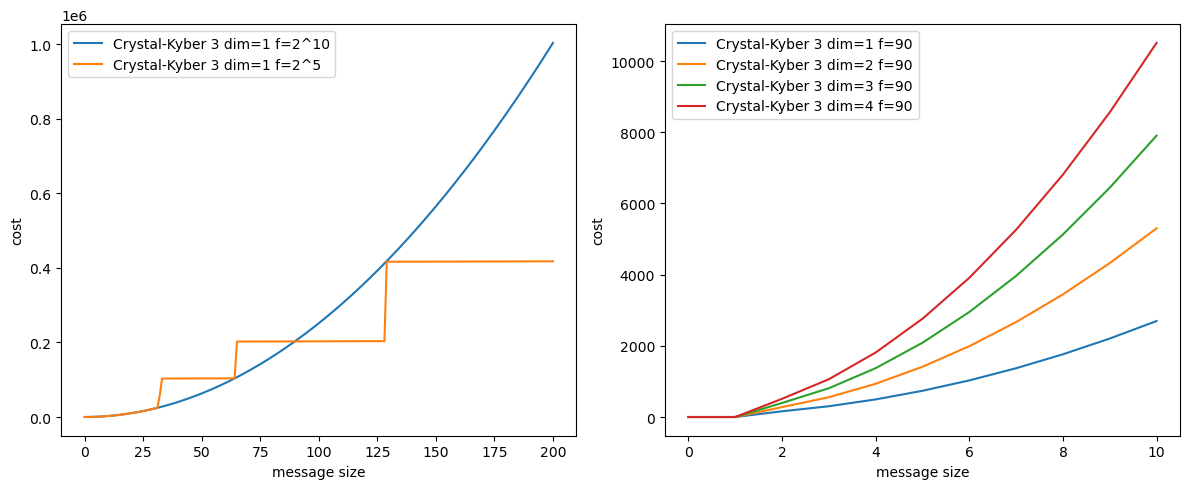

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Create x values
x1 = np.linspace(0, 200, 200 + 1)
y1 = np.zeros((len(x1), 1))
y2 = np.zeros((len(x1), 1))
y3 = np.zeros((len(x1), 1))
y4 = np.zeros((len(x1), 1))

x2 = np.linspace(0, 1000, int(1000 + 1))
y1a = np.zeros((len(x2), 1))
y2a = np.zeros((len(x2), 1))
y3a = np.zeros((len(x2), 1))
y4a = np.zeros((len(x2), 1))
y5a = np.zeros((len(x2), 1))

add_count = 0
mul_count = 0
shift_count = 0


for n2 in range(len(x1)):
    # global add_count, mul_count, shift_count
    if n2 > 1 and n2 < len(x1):

        add_count = 0
        mul_count = 0
        shift_count = 0
        n_123 = n2  # Polynomial degree (len bits)
        q = 3329  # 998244353       # Modulus (prime)
        flip = 2 ** 10
        dim = 1

        add_count = 0
        mul_count = 0
        shift_count = 0

        pk, sk = keygen_c()
        message = random_message(n_123)
        ct = encrypt_rlwe_style_c(pk, message)
        recovered = decrypt_rlwe_style_c(sk, ct)

        if remove_trailing_zeros(recovered) == remove_trailing_zeros(message):
            y2[n2] = mul_count * 4 + add_count + shift_count
        else:
            print('y2 error')
            print(f' found {remove_trailing_zeros(recovered)} but expected {remove_trailing_zeros(message)}')

        add_count = 0
        mul_count = 0
        shift_count = 0
        flip = 2 ** 5

        add_count = 0
        mul_count = 0
        shift_count = 0

        pk, sk = keygen_c()
        message = random_message(n_123)
        ct = encrypt_rlwe_style_c(pk, message)
        recovered = decrypt_rlwe_style_c(sk, ct)

        if remove_trailing_zeros(recovered) == remove_trailing_zeros(message):
            y4[n2] = mul_count * 4 + add_count + shift_count
        else:
            print('y4 error')
            print(f' found {remove_trailing_zeros(recovered)} but expected {remove_trailing_zeros(message)}')

for n2 in range(len(x2)):
    # global add_count, mul_count, shift_count
    if n2 > 1 and n2 < len(x2):

        # global flip
        add_count = 0
        mul_count = 0
        shift_count = 0
        n_123 = n2  # Polynomial degree (len bits)
        q = 998244353  # Modulus (prime)
        flip = 90
        dim = 1

        add_count = 0
        mul_count = 0
        shift_count = 0
        dim = 1
        flip = 90

        pk, sk = keygen_c()
        message = random_message(n_123)
        ct = encrypt_rlwe_style_c(pk, message)
        recovered = decrypt_rlwe_style_c(sk, ct)

        if remove_trailing_zeros(recovered) == remove_trailing_zeros(message):
            y2a[n2] = mul_count * 4 + add_count + shift_count
        else:
            print('y2a error')
            print(f' found {remove_trailing_zeros(recovered)} but expected {remove_trailing_zeros(message)}')

        add_count = 0
        mul_count = 0
        shift_count = 0
        dim = 2

        pk, sk = keygen_c()
        message = random_message(n_123)
        ct = encrypt_rlwe_style_c(pk, message)
        recovered = decrypt_rlwe_style_c(sk, ct)

        if remove_trailing_zeros(recovered) == remove_trailing_zeros(message):
            y3a[n2] = mul_count * 4 + add_count + shift_count
        else:
            print('y3a error')
            print(f' found {remove_trailing_zeros(recovered)} but expected {remove_trailing_zeros(message)}')

        add_count = 0
        mul_count = 0
        shift_count = 0
        dim = 3

        pk, sk = keygen_c()
        message = random_message(n_123)
        ct = encrypt_rlwe_style_c(pk, message)
        recovered = decrypt_rlwe_style_c(sk, ct)

        if remove_trailing_zeros(recovered) == remove_trailing_zeros(message):
            y4a[n2] = mul_count * 4 + add_count + shift_count
        else:
            print('y4a error')
            print(f' found {remove_trailing_zeros(recovered)} but expected {remove_trailing_zeros(message)}')

        add_count = 0
        mul_count = 0
        shift_count = 0
        dim = 4

        pk, sk = keygen_c()
        message = random_message(n_123)
        ct = encrypt_rlwe_style_c(pk, message)
        recovered = decrypt_rlwe_style_c(sk, ct)

        if remove_trailing_zeros(recovered) == remove_trailing_zeros(message):
            y5a[n2] = mul_count * 4 + add_count + shift_count
        else:
            print('y5a error')
            print(f' found {remove_trailing_zeros(recovered)} but expected {remove_trailing_zeros(message)}')

# Create two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(x1, y2, label='Crystal-Kyber 3 dim=1 f=2^10')
ax1.plot(x1, y4, label='Crystal-Kyber 3 dim=1 f=2^5')
ax1.set_xlabel('message size')
ax1.set_ylabel('cost')
ax1.legend()

ax2.plot(x2, y2a, label='Crystal-Kyber 3 dim=1 f=90')
ax2.plot(x2, y3a, label='Crystal-Kyber 3 dim=2 f=90')
ax2.plot(x2, y4a, label='Crystal-Kyber 3 dim=3 f=90')
ax2.plot(x2, y5a, label='Crystal-Kyber 3 dim=4 f=90')
ax2.set_xlabel('message size')
ax2.set_ylabel('cost')
ax2.legend()
plt.tight_layout()
plt.show()